# 🧠 Data Preprocessing Project

### 📊 Dataset: Workout and Fitness Tracker Data  
📁 Source: [Kaggle - Workout and Fitness Tracker](https://www.kaggle.com/datasets/adilshamim8/workout-and-fitness-tracker-data)

---

## 👨‍💻 Student Information
- **Name:** Yrysbaev Maksatbek  
- **Course:** Data Mining  
- **Instructor:** Sabina Adhikari  
- **Date:** 8 April 2025  

---

## 📝 Assignment Overview

This project applies essential **data preprocessing techniques** to a real-world dataset. The goal is to prepare the data for analysis and modeling by implementing the following five steps:

1. **Data Cleaning** – Handle missing values, duplicates, and incorrect data types.  
2. **Data Reduction** – Apply PCA to reduce dimensionality and visualize major components.  
3. **Data Transformation** – Normalize numerical data using MinMaxScaler.  
4. **Data Discretization** – Convert continuous data into categorical bins for easier analysis.  
5. **(Optional) Data Integration** – Optionally support dataset merging if needed.

All steps are demonstrated using Python libraries like **Pandas, NumPy, Matplotlib, Seaborn**, and **scikit-learn**.

---


## Step 1: Import Required Libraries

We start by importing essential libraries:
- `pandas` and `numpy` for data manipulation
- `matplotlib` and `seaborn` for data visualization
- `sklearn` for normalization and PCA (Principal Component Analysis)

We also enable inline plotting to show graphs directly in the notebook.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

%matplotlib inline

## Step 2: Load the Dataset

We load the dataset using `pandas.read_csv()` and display the first few rows using `head()`. 
Make sure the dataset file (`workout.csv`) is in the correct path (e.g., inside a `data/` folder).


In [8]:
# Load the dataset
df = pd.read_csv('../data/workout.csv')  # or just 'workout.csv' if it’s in the same folder

# Preview first rows
df.head()


,User ID,Age,Gender,Height (cm),Weight (kg),Workout Type,Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Workout Intensity,Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%),Mood Before Workout,Mood After Workout
0,1,39,Male,175,99,Cycling,79,384,112,8850,14.44,High,8.2,1.9,3195,61,38.4,28.5,Tired,Fatigued
1,2,36,Other,157,112,Cardio,73,612,168,2821,1.10,High,8.6,1.9,2541,73,38.4,28.5,Happy,Energized
2,3,25,Female,180,66,HIIT,27,540,133,18898,7.28,High,9.8,1.9,3362,80,38.4,28.5,Happy,Fatigued
3,4,56,Male,154,89,Cycling,39,672,118,14102,6.55,Medium,5.8,1.9,2071,65,38.4,28.5,Neutral,Neutral
4,5,53,Other,194,59,Strength,56,410,170,16518,3.17,Medium,7.3,1.9,3298,59,38.4,28.5,Stressed,Energized


## Step 3: Data Cleaning

In this step, we clean the data by:
- Checking for missing values
- Handling null values (e.g., dropping them)
- Removing duplicates
- Reviewing data types to make sure everything is correct


In [9]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Drop rows with missing values (or you can use df.fillna() if preferred)
df = df.dropna()

# Remove duplicate rows, if any
df = df.drop_duplicates()

# Display updated dataset info
print("\nUpdated Data Info:")
df.info()


Missing values in each column:
User ID                     0
Age                         0
Gender                      0
Height (cm)                 0
Weight (kg)                 0
Workout Type                0
Workout Duration (mins)     0
Calories Burned             0
Heart Rate (bpm)            0
Steps Taken                 0
Distance (km)               0
Workout Intensity           0
Sleep Hours                 0
Water Intake (liters)       0
Daily Calories Intake       0
Resting Heart Rate (bpm)    0
VO2 Max                     0
Body Fat (%)                0
Mood Before Workout         0
Mood After Workout          0
dtype: int64

Updated Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User ID                   10000 non-null  int64  
 1   Age                       10000 non-null  int64  
 2   Gen

## Step 4: Data Reduction (PCA)

To simplify the dataset and reduce complexity, we apply **Principal Component Analysis (PCA)** to numeric features. PCA helps reduce the number of variables while retaining most of the important information. We also visualize the result using a scatter plot of the first two principal components.


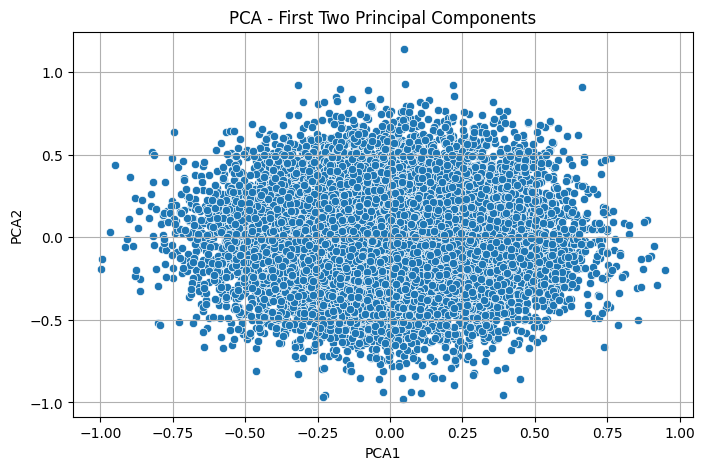

In [10]:
# Select only numeric columns for PCA
numeric_df = df.select_dtypes(include=[np.number])

# Check for empty numeric columns
if numeric_df.empty:
    print("No numeric columns found for PCA.")
else:
    # Normalize the data before PCA
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(numeric_df)

    # Apply PCA (reduce to 2 components for visualization)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)

    # Convert to DataFrame for plotting
    df_pca = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])

    # Visualize
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x='PCA1', y='PCA2', data=df_pca)
    plt.title('PCA - First Two Principal Components')
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.grid(True)
    plt.show()


## Step 5: Data Transformation (Normalization)

Normalization scales numeric features into a common range, usually between 0 and 1. This step is important for many machine learning algorithms and visualizations. We use `MinMaxScaler` from `sklearn.preprocessing` to normalize the numeric columns in the dataset.


In [11]:
# Normalize numeric columns using MinMaxScaler
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(numeric_df)

# Convert to DataFrame with original column names
df_normalized = pd.DataFrame(normalized_data, columns=numeric_df.columns)

# Display the first few rows of the normalized data
df_normalized.head()


,User ID,Age,Height (cm),Weight (kg),Workout Duration (mins),Calories Burned,Heart Rate (bpm),Steps Taken,Distance (km),Sleep Hours,Water Intake (liters),Daily Calories Intake,Resting Heart Rate (bpm),VO2 Max,Body Fat (%)
0,0.0000,0.512195,0.510204,0.710145,0.633028,0.315907,0.323232,0.413201,0.961379,0.700000,0.0,0.678271,0.282051,0.0,0.0
1,0.0001,0.439024,0.142857,0.898551,0.577982,0.569522,0.888889,0.095852,0.041379,0.766667,0.0,0.416567,0.589744,0.0,0.0
2,0.0002,0.170732,0.612245,0.231884,0.155963,0.489433,0.535354,0.942099,0.467586,0.966667,0.0,0.745098,0.769231,0.0,0.0
3,0.0003,0.926829,0.081633,0.565217,0.266055,0.636263,0.383838,0.689652,0.417241,0.300000,0.0,0.228491,0.384615,0.0,0.0
4,0.0004,0.853659,0.897959,0.130435,0.422018,0.344828,0.909091,0.816823,0.184138,0.550000,0.0,0.719488,0.230769,0.0,0.0
